## 7.4 梯度优化方法 - Adam（梯度 + 学习率）


#### 1. 为什么需要 Adam
在前面的学习中，我们已经介绍了几种优化方法。
```
方法	解决的问题
Momentum	减少梯度震荡
AdaGrad	自适应学习率
RMSProp	避免学习率无限减小
```
但这些方法仍然存在一些不足：

##### 1.1 Momentum
只能：
* 优化梯度方向和大小

但：
* 学习率仍然固定

##### 1.2 AdaGrad
只能：
* 优化学习率大小

但是：
* 学习率可能无限缩小

##### 1.3 RMSProp
可以：
* 动态调节学习率

但是：
* 没有利用梯度方向的历史信息

因此提出 Adam：

`同时使用 Momentum + RMSProp 的思想`

#### 2. Adam 的核心思想
Adam 使用两个指数移动平均：
```
变量	作用
m_t	梯度的 EMA（Momentum）
v_t	梯度平方的 EMA（RMSProp）
```
也就是说：
* Adam 同时平滑梯度
* 并动态调整学习率

#### 3. Adam 的数学公式
Adam 的核心有 四个步骤。

**1️⃣ 计算当前梯度**

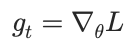

**2️⃣ 计算梯度的 EMA（Momentum）**

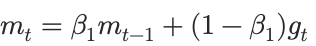

其中：

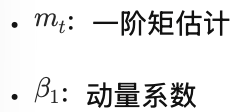

3️⃣ 计算梯度平方的 EMA（RMSProp）

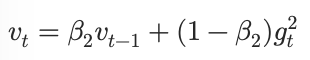

其中：

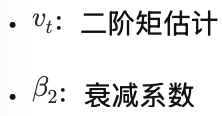

#### 4. Bias Correction（偏差修正）
由于：
```
m₀ = 0
v₀ = 0
```
问题出现了：

##### 4.1 第一步会发生什么
假设：
```
β₁ = 0.9
```
第一步：

![m1 = 0.9×0+0.191.png](<attachment:m1 = 0.9×0+0.191.png>)

所以：

![my = 0.191.png](<attachment:my = 0.191.png>)

但如果是真正的 EMA 平均，第一步应该接近：
* g₁

而不是
* 0.1 g₁

所以：
* m₁ 被严重低估
* 这就是 初始化偏差。
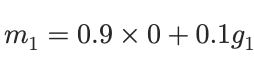
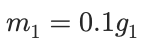

##### 4.2 解决初始化偏差
在 Adam 中，每一步计算出 m_t 和 v_t 之后，都会进行一次 Bias Correction，然后再用修正后的值更新参数。

因此 Adam 使用 偏差修正：

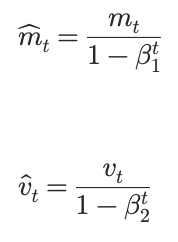

第一步：

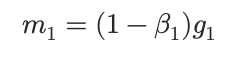

Bias correction：

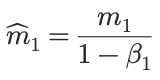

带入：

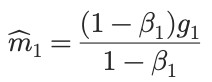

得到：

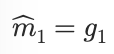

这就恢复了真实值。


##### 4.3 为什么每一步都要修正
因为：
* EMA 的偏差会持续存在一段时间

例如：
* t = 1  偏差最大
* t = 2  仍然有偏差
* t = 10 偏差已经很小

```
	β₁^t (β₁=0.9)	1−β₁^t
1	0.9	0.1
5	0.59	0.41
10	0.35	0.65
50	0.005	0.995
```

所以：
* 训练几十步之后
* bias correction 基本没有影响

但：
* 如果没有 bias correction
* * 训练初期更新会非常慢


##### 5. 参数更新公式
Adam 的参数更新可以拆成 两个部分：

`参数更新 = 学习率优化 × 梯度方向`

##### 5.1 学习率优化部分（来自 RMSProp）
首先计算 自适应学习率：

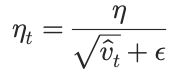

其中：

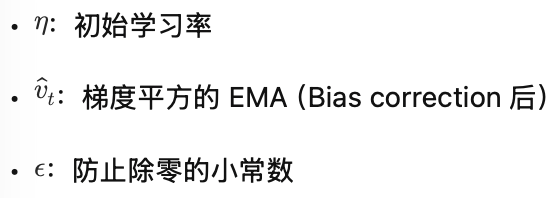

这一部分的作用是：
* 根据梯度大小动态调整学习率

如果：
* 梯度大 → 学习率变小
* 梯度小 → 学习率变大

##### 5.2 梯度方向（来自 Momentum）
Momentum 部分：

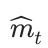

表示：
* 梯度的指数移动平均

作用是：
* 平滑梯度方向
* 减少震荡

#####  5.3 最终参数更新
最终 Adam 的更新公式：

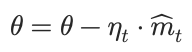

其中：

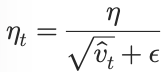



#### 6. Adam 的直观理解 
Adam 可以理解为：
```
参数更新
=
(自适应学习率)
×
(平滑后的梯度)
```
具体来说：

##### Momentum 部分
作用：
* 平滑梯度方向
* 减少震荡。

##### RMSProp 部分
作用：
* 动态调整学习率
* 避免更新过大。

因此 Adam 的更新方向是：
* 平滑梯度
* 梯度尺度

这会得到：
* 稳定且自适应的更新步长

#### 7. Adam 的算法流程
每个训练 batch：

##### Step1
计算梯度

`g_t = ∇L`

##### Step2
更新一阶矩

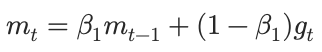

##### Step3
更新二阶矩

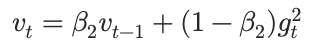

##### Step4
偏差修正

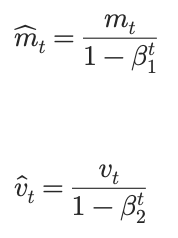


##### Step5
更新参数

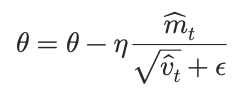

#### 8. Adam 的默认参数
在大多数深度学习框架中：
```
参数	默认值
learning rate	0.001
β₁	0.9
β₂	0.999
ε	1e-8
```
这些参数在大多数任务中都表现良好。

##### 9. Adam 的优点
Adam 具有很多优点：

**1️⃣ 收敛速度快**
结合：
* Momentum + RMSProp

可以：
* 快速找到合适更新方向

**2️⃣ 自适应学习率**
每个参数都有：
* 独立学习率

**3️⃣ 对超参数不敏感**
通常：
* 默认参数即可工作

**4️⃣ 适用于大多数深度学习任务**
例如：
```
CNN
RNN
Transformer
```

#### 10. Adam 的缺点
Adam 也存在一些问题：

**1️⃣ 有时泛化能力略差**

相比：

`SGD + Momentum`

Adam 在某些任务中：

泛化能力略差

**2️⃣ 理论分析复杂**

Adam 的收敛性质比 SGD 更复杂。

#### 11. Adam 在 Pytorch 中的实现
在 Pytorch 中，Adam 使用：

`torch.optim.Adam`

##### 11.1 基本写法

In [ ]:
import torch 

model = torch.nn.Linear(1, 1)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

##### 11.2 常见参数

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=0
)

##### 11.3 参数说明
* lr
    * 学习率
* betas=(0.9, 0.999)
    * 第一个值：梯度 EMA 的系数，对应 Momentum 的 beta_1
    * 第二个值：梯度平方 EMA 的系数，对应 RMSProp 的 beta_2
* eps
    * 防止除零的小常数
* weight_decay
    * L2 正则化系数